In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_curve, auc
from sklearn.utils import class_weight
from sklearn.manifold import TSNE
import torch

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import sys

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import cv2

/opt/anaconda3/envs/cameratrapenv/lib/python3.10/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
# Define standard parameters
IMG_SIZE = (224, 224) # Standard for most pre-trained models
BATCH_SIZE = 32

# Load the training data
train_data = tf.keras.utils.image_dataset_from_directory(
    'kalahari_classification_dataset/train',
    label_mode='categorical',
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

species_list = train_data.class_names

# Load the validation data
val_data = tf.keras.utils.image_dataset_from_directory(
    'kalahari_classification_dataset/val',
    label_mode='categorical',
    shuffle=False, # No need to shuffle validation data
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

print(len(species_list))

Found 1143 files belonging to 25 classes.
Found 142 files belonging to 30 classes.
25


In [ ]:
train_labels = np.concatenate([y for x, y in train_data], axis=0)
if len(train_labels.shape) > 1: # if categorical
    train_labels = np.argmax(train_labels, axis=1)

# 2. Calculate weights (higher weight for classes with fewer images)
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# 3. Turn into a dictionary {class_index: weight}
class_weight_dict = dict(enumerate(weights))

2026-03-07 17:21:16.702397: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


{0: np.float64(22.86),
 1: np.float64(0.0755702479338843),
 2: np.float64(15.24),
 3: np.float64(3.048),
 4: np.float64(0.9727659574468085),
 5: np.float64(7.62),
 6: np.float64(1.4748387096774194),
 7: np.float64(0.5195454545454545),
 8: np.float64(1.4748387096774194),
 9: np.float64(45.72),
 10: np.float64(0.24449197860962568),
 11: np.float64(4.572),
 12: np.float64(15.24),
 13: np.float64(1.6328571428571428),
 14: np.float64(9.144),
 15: np.float64(5.08),
 16: np.float64(1.905),
 17: np.float64(11.43),
 18: np.float64(5.08),
 19: np.float64(2.078181818181818),
 20: np.float64(15.24),
 21: np.float64(45.72),
 22: np.float64(6.531428571428571),
 23: np.float64(45.72),
 24: np.float64(45.72)}

In [4]:
# 1. Load a pre-trained base (without the top layer)
base_model = tf.keras.applications.EfficientNetV2B1(weights='imagenet', include_top=False)
base_model.trainable = False  # Freeze it first


In [ ]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal_and_vertical"),
  tf.keras.layers.RandomRotation(0.2),
  tf.keras.layers.RandomZoom(0.2),
  tf.keras.layers.RandomContrast(0.2),
])

# Add it to your model
model = tf.keras.Sequential([
    data_augmentation,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(len(species_list), activation='softmax')
])

In [6]:

# 3. Train the head (Phase 1)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='categorical_crossentropy')
model.fit(train_data, epochs=10)



Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 21s 419ms/step - loss: 3.0001
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 17s 480ms/step - loss: 1.3804
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 17s 485ms/step - loss: 1.2636
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 18s 485ms/step - loss: 1.0873
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 18s 496ms/step - loss: 0.9543
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 19s 530ms/step - loss: 0.8667
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 18s 494ms/step - loss: 0.8033
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 17s 480ms/step - loss: 0.7761
Epoch 9/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 545ms/step - loss: 0.7478
Epoch 10/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 559ms/step - loss: 0.6929


In [ ]:
# 4. Fine-tune the base (Phase 2)
base_model.trainable = True
# Only unfreeze the last 20 layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), loss='categorical_crossentropy')
model.fit(train_data, epochs=30, class_weight=class_weight_dict)

Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 26s 522ms/step - loss: 1.8235
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 562ms/step - loss: 1.7344
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 21s 581ms/step - loss: 1.7943
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 548ms/step - loss: 1.7676
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 551ms/step - loss: 1.7237
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 22s 605ms/step - loss: 1.8037
Epoch 7/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 21s 580ms/step - loss: 1.7010
Epoch 8/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 21s 594ms/step - loss: 1.6875
Epoch 9/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 27s 744ms/step - loss: 1.7301
Epoch 10/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 26s 709ms/step - loss: 1.7577
Epoch 11/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 24s 678ms/step - loss: 1.7500
Epoch 12/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 28s 764ms/step - loss: 1.7387
Epoch 13/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 27s 741ms/step - loss: 1.6986
Epoch 14/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 24s 672ms/step - loss: 1.7267
Epoch 15/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 27s 

In [ ]:
test_data = tf.keras.utils.image_dataset_from_directory(
    'kalahari_classification_dataset/test',
    label_mode='categorical',
    shuffle=False, # No need to shuffle validation data
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

Found 147 files belonging to 25 classes.


In [ ]:
y_true_categorical = np.concatenate([y for x, y in test_data], axis=0)

y_true = np.argmax(y_true_categorical, axis=1)

predictions = model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)

test_species_names = test_data.class_names

print(classification_report(y_true, y_pred))

2026-03-07 14:32:08.587666: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 797ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.98      0.84      0.91        69
           2       0.20      1.00      0.33         1
           3       0.33      1.00      0.50         1
           4       0.33      0.10      0.15        10
           6       0.67      1.00      0.80         4
           7       0.86      1.00      0.92        18
           8       0.25      1.00      0.40         1
           9       0.00      0.00      0.00         1
          10       1.00      0.81      0.89        26
          11       1.00      1.00      1.00         1
          12       1.00      0.33      0.50         3
          13       1.00      1.00      1.00         3
          15       0.33      0.50      0.40         2
          17       0.00      0.00      0.00         1
          18       1.00      0.50      0.67         2
          19       0.43      1.00      0.6

/opt/anaconda3/envs/cameratrapenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/cameratrapenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/cameratrapenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()

/var/folders/q6/dh9_zk1x5m94wr74c96ngwf40000gn/T/ipykernel_88715/826890934.py:3: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


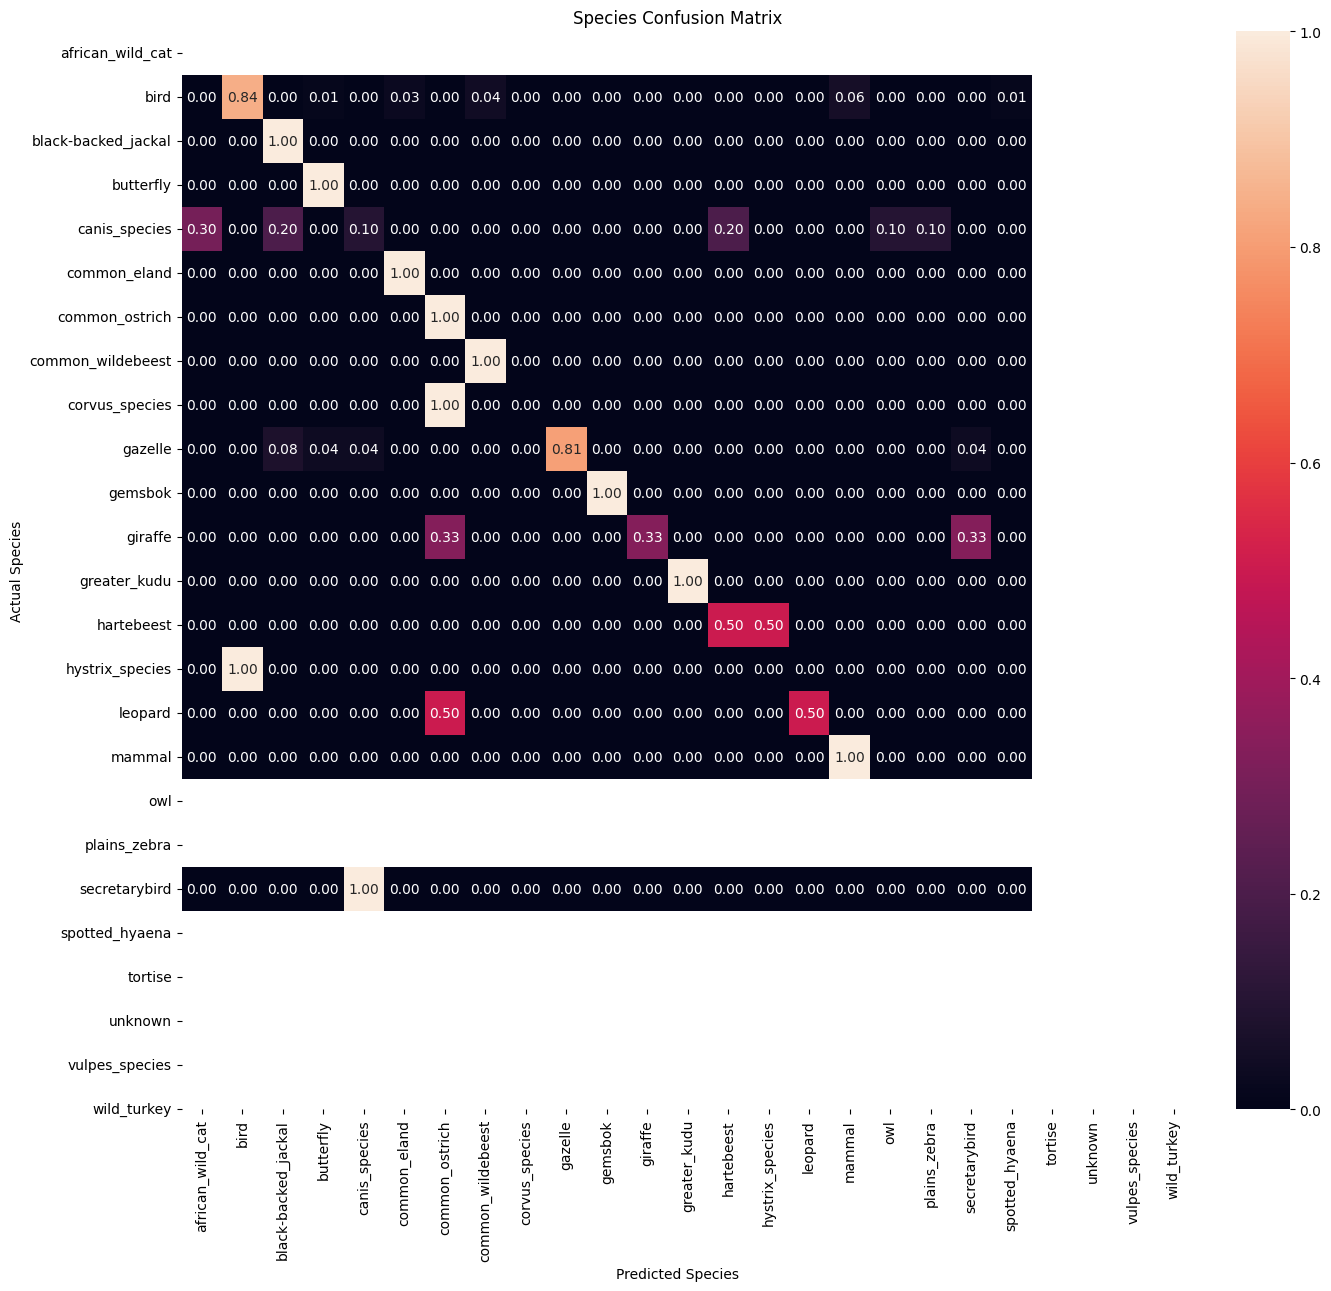

In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(16, 14))
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2f', xticklabels=test_species_names, yticklabels=test_species_names)
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')
plt.title('Species Confusion Matrix')
plt.show()

In [ ]:
acc = accuracy_score(y_true, y_pred)

print(f"Model Accuracy: {acc * 100:.2f}%")

Model Accuracy: 78.23%


In [ ]:
print("Train classes:", train_data.class_names)
print("Test classes:", test_data.class_names)

Train classes: ['african_wild_cat', 'bird', 'black-backed_jackal', 'butterfly', 'canis_species', 'common_eland', 'common_ostrich', 'common_wildebeest', 'corvus_species', 'gazelle', 'gemsbok', 'giraffe', 'greater_kudu', 'hartebeest', 'hystrix_species', 'leopard', 'mammal', 'owl', 'plains_zebra', 'secretarybird', 'spotted_hyaena', 'tortise', 'unknown', 'vulpes_species', 'wild_turkey']
Test classes: ['african_wild_cat', 'bird', 'black-backed_jackal', 'butterfly', 'canis_species', 'common_eland', 'common_ostrich', 'common_wildebeest', 'corvus_species', 'gazelle', 'gemsbok', 'giraffe', 'greater_kudu', 'hartebeest', 'hystrix_species', 'leopard', 'mammal', 'owl', 'plains_zebra', 'secretarybird', 'spotted_hyaena', 'tortise', 'unknown', 'vulpes_species', 'wild_turkey']


5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 837ms/step


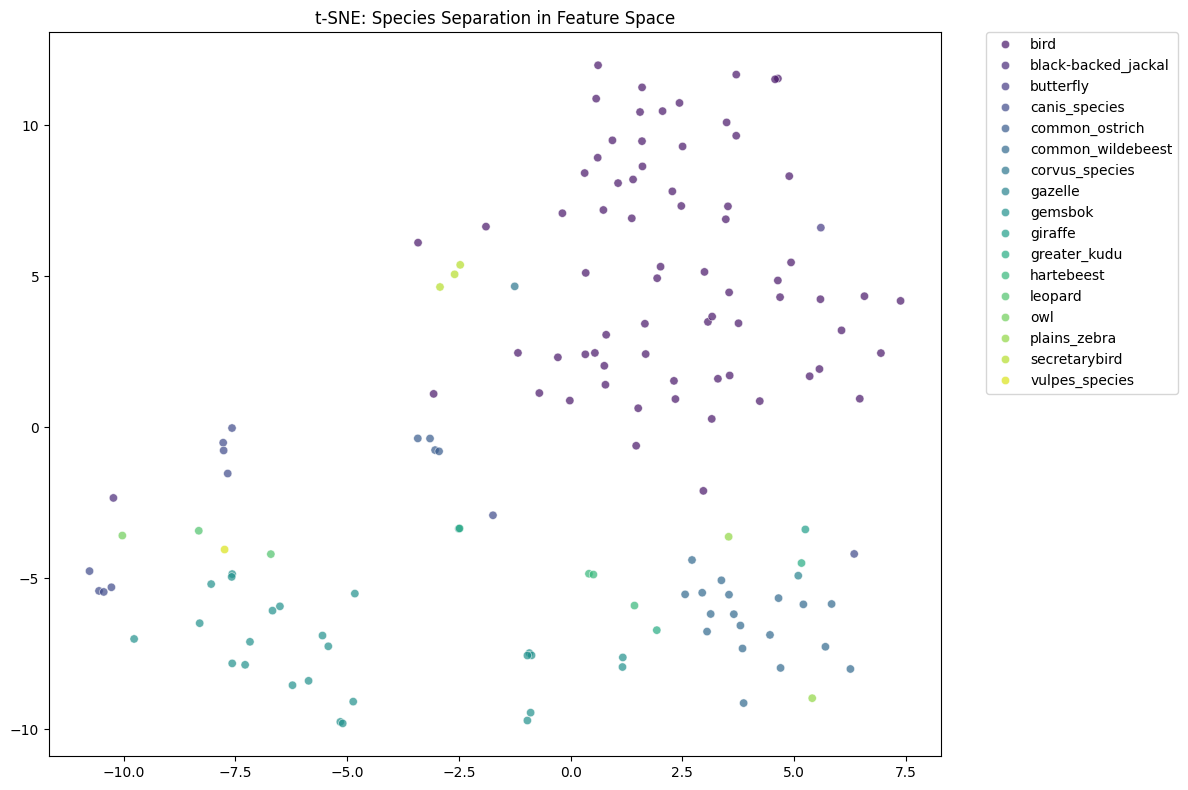

In [ ]:
# 1. Create a "Feature Extractor" (the model minus the last Dense layer)
sample_images, _ = next(iter(test_data))
model(sample_images) 

# feature_extractor = tf.keras.Model(model.layers[:-2])

# 2. Get the "embeddings" (numerical fingerprints) for your 2,000 images
# embeddings = feature_extractor.predict(test_data)

input_shape = (224, 224, 3) 
x_input = tf.keras.Input(shape=input_shape)

# 2. Reconstruct the path through your model layers
# We iterate through all layers EXCEPT the last one (the classifier)
x = x_input
for layer in model.layers[:-1]:
    x = layer(x)

# 3. Create the feature extractor using this new explicit path
feature_extractor = tf.keras.Model(inputs=x_input, outputs=x)

# 4. Now run your prediction
# Ensure test_data images are resized to the same input_shape
embeddings = feature_extractor.predict(test_data)

# 3. Reduce 1280 dimensions down to 2 for plotting
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
reduced_data = tsne.fit_transform(embeddings)

y_true_labels = np.array(y_true).flatten()

# 2. Map the integer indices to the actual names
# We use a list comprehension to create a list of strings for Seaborn
hue_labels = [test_species_names[int(i)] for i in y_true_labels]

# 3. Plot using the mapped names
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=reduced_data[:, 0], 
    y=reduced_data[:, 1], 
    hue=hue_labels, 
    palette='viridis',
    legend='full',
    alpha=0.7
)

# 4. Clean up the legend (it can get crowded with 25 species)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.title("t-SNE: Species Separation in Feature Space")
plt.tight_layout()
plt.show()

In [ ]:
preds = model.predict(test_data)
pred_indices = np.argmax(preds, axis=1)

# Find indices where prediction != truth
errors = np.where(pred_indices != y_true)[0]

# 2. Sort by confidence (how sure was the model of its wrong answer?)
error_confidences = [preds[i][pred_indices[i]] for i in errors]
top_errors = errors[np.argsort(error_confidences)[-5:]]

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 488ms/step


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 466ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 518ms/step


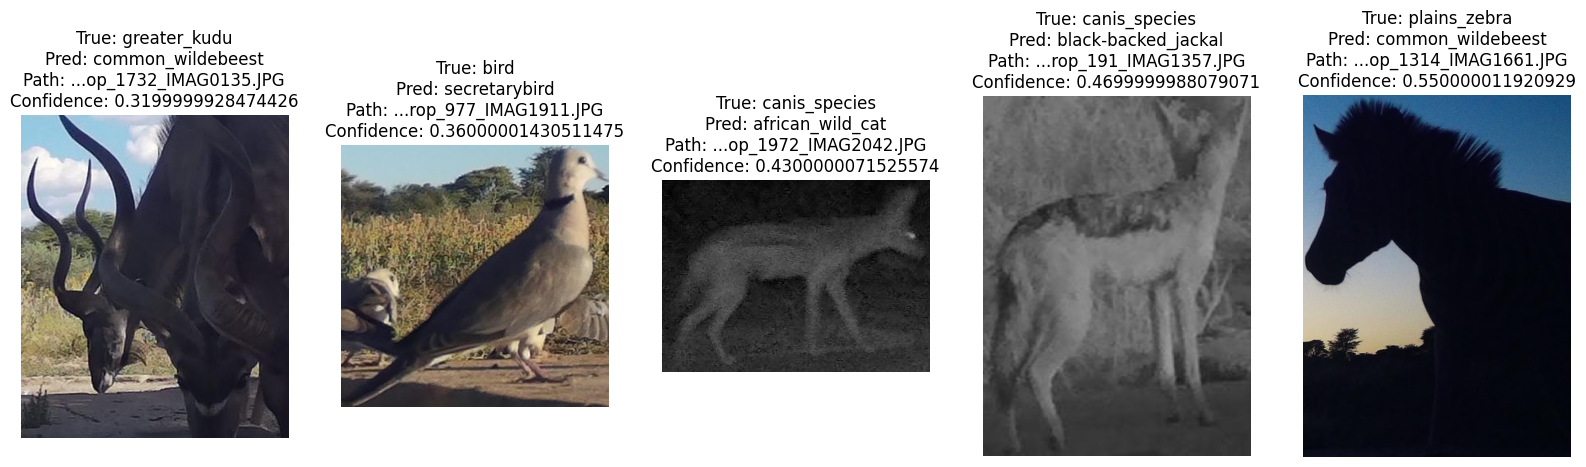

In [ ]:
preds = model.predict(test_data)
pred_indices = np.argmax(preds, axis=1)

# Find indices where prediction != truth
errors = np.where(pred_indices != y_true)[0]

# 2. Sort by confidence (how sure was the model of its wrong answer?)
error_confidences = [preds[i][pred_indices[i]] for i in errors]
top_errors = errors[np.argsort(error_confidences)[-5:]]

all_filepaths = test_data.file_paths

# 2. Get your predictions (ensure these are for the whole test set)
predictions = model.predict(test_data)
pred_indices = np.argmax(predictions, axis=1)

# 3. Create a simple lookup function
def get_image_info(idx):
    path = all_filepaths[idx]
    actual_label = test_species_names[y_true[idx]]
    pred_label = test_species_names[pred_indices[idx]]
    confidence = np.max(predictions[idx])
    
    return path, actual_label, pred_label, confidence

errors = np.where(pred_indices != y_true)[0]

plt.figure(figsize=(20, 10))

for i, err_idx in enumerate(top_errors): # Just the first 5 errors
    path = all_filepaths[err_idx]
    true_name = test_species_names[y_true[err_idx]]
    pred_name = test_species_names[pred_indices[err_idx]]
    confidence = np.max(predictions[err_idx])
    
    plt.subplot(1, 5, i+1)
    img = mpimg.imread(path)
    plt.imshow(img)
    plt.title(f"True: {true_name}\nPred: {pred_name}\nPath: ...{path[-20:]}\nConfidence: {np.round(confidence, 2)}")
    plt.axis('off')

plt.show()

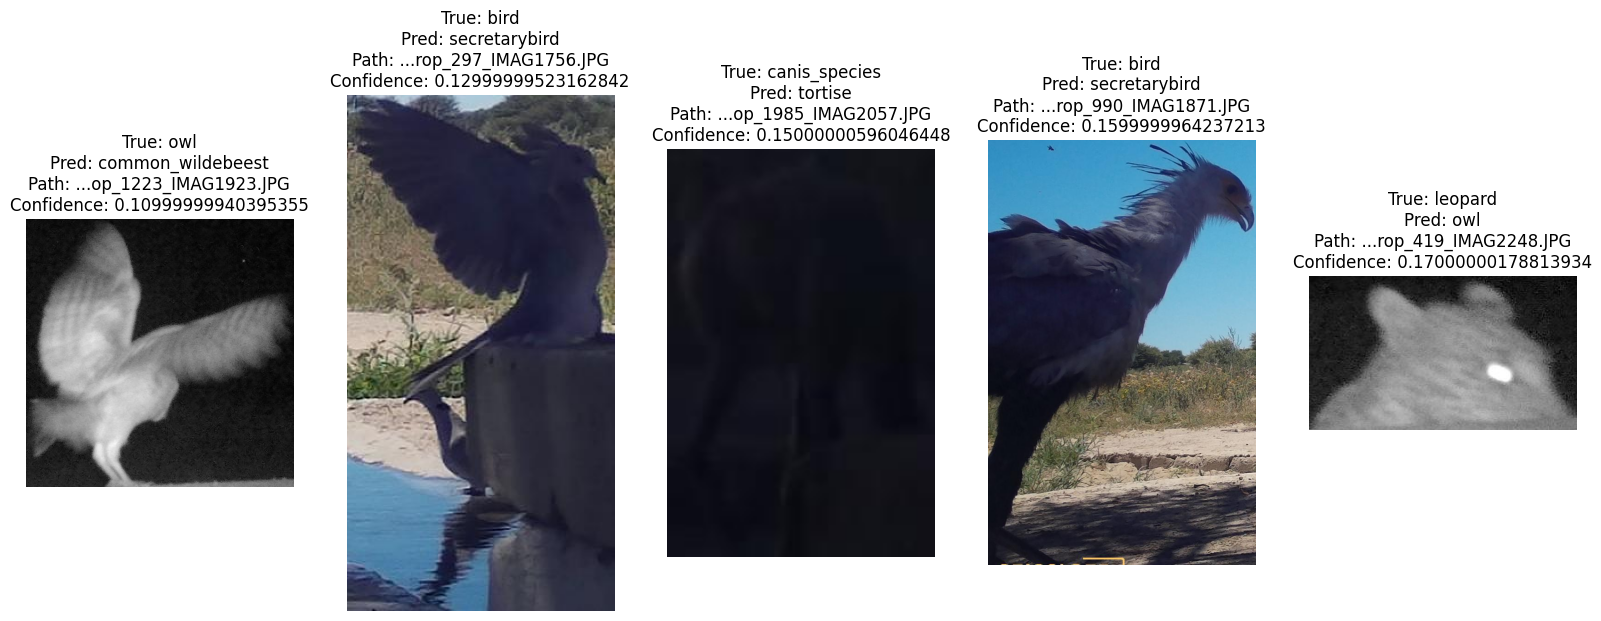

In [ ]:
bottom_errors = errors[np.argsort(error_confidences)[:5]]


plt.figure(figsize=(20, 10))

for i, err_idx in enumerate(bottom_errors): # Just the first 5 errors
    path = all_filepaths[err_idx]
    true_name = test_species_names[y_true[err_idx]]
    pred_name = test_species_names[pred_indices[err_idx]]
    confidence = np.max(predictions[err_idx])
    
    plt.subplot(1, 5, i+1)
    img = mpimg.imread(path)
    plt.imshow(img)
    plt.title(f"True: {true_name}\nPred: {pred_name}\nPath: ...{path[-20:]}\nConfidence: {np.round(confidence, 2)}")
    plt.axis('off')

plt.show()

In [ ]:
def get_gradcam(img_array, model, last_conv_layer_name, pred_index):
    # 1. Create a model that outputs the last conv layer activations
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # 2. Compute the gradient of the predicted class with respect to the activations
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, pred_index]

    # 3. Extract gradients and weight the feature map channels
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    # 4. Normalize for visualization
    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)
    return heatmap

In [ ]:
model.summary()

# Figure out how to filter out the least confident guesses for manual review

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b1 (Functional)  │ (None, 7, 7, 1280)     │     6,931,124 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 25)             │        32,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,662,881 (33.05 MB)

 Trainable params: 849,865 (3.24 MB)

 Non-trainable params: 6,113,284 (23.32 MB)

 Optimizer params: 1,699,732 (6.48 MB)

In [ ]:
# 1. Get predictions on the TRAINING set (not the test set)
# Ensure shuffle=False so labels match file order
train_predictions = model.predict(train_data)
y_pred_train = np.argmax(train_predictions, axis=1)

# 2. Extract the true labels from the generator
y_true_raw = np.concatenate([y for x, y in train_data], axis=0)

# FIX: Convert the one-hot vectors into single integers (0, 1, 2...)
y_true_train = np.argmax(y_true_raw, axis=1)# If using sparse categorical crossentropy, y_true_train is already indices. 
# If one-hot, use: y_true_train = np.argmax(y_true_train, axis=1)

# 3. Calculate Accuracy
train_acc = accuracy_score(y_true_train, y_pred_train)
print(f"Custom Model Training Accuracy: {train_acc * 100:.2f}%")

# 4. Detailed Report
print(classification_report(y_true_train, y_pred_train, target_names=train_data.class_names))

36/36 ━━━━━━━━━━━━━━━━━━━━ 15s 428ms/step
Custom Model Training Accuracy: 73.93%
                     precision    recall  f1-score   support

   african_wild_cat       0.07      1.00      0.14         2
               bird       0.99      0.75      0.85       605
black-backed_jackal       0.16      1.00      0.27         3
          butterfly       0.39      0.93      0.55        15
      canis_species       0.55      0.26      0.35        47
       common_eland       0.33      0.17      0.22         6
     common_ostrich       0.58      0.97      0.72        31
  common_wildebeest       0.80      0.89      0.84        88
     corvus_species       0.44      0.87      0.58        31
            gazelle       0.20      1.00      0.33         1
            gemsbok       0.95      0.68      0.79       187
            giraffe       0.91      1.00      0.95        10
       greater_kudu       1.00      0.33      0.50         3
         hartebeest       0.81      0.75      0.78        28
   

In [ ]:
raw_extractor = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D()
])

# Get "General" fingerprints
raw_embeddings = raw_extractor.predict(train_data)

custom_embeddings = feature_extractor.predict(train_data)

36/36 ━━━━━━━━━━━━━━━━━━━━ 17s 446ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 17s 463ms/step


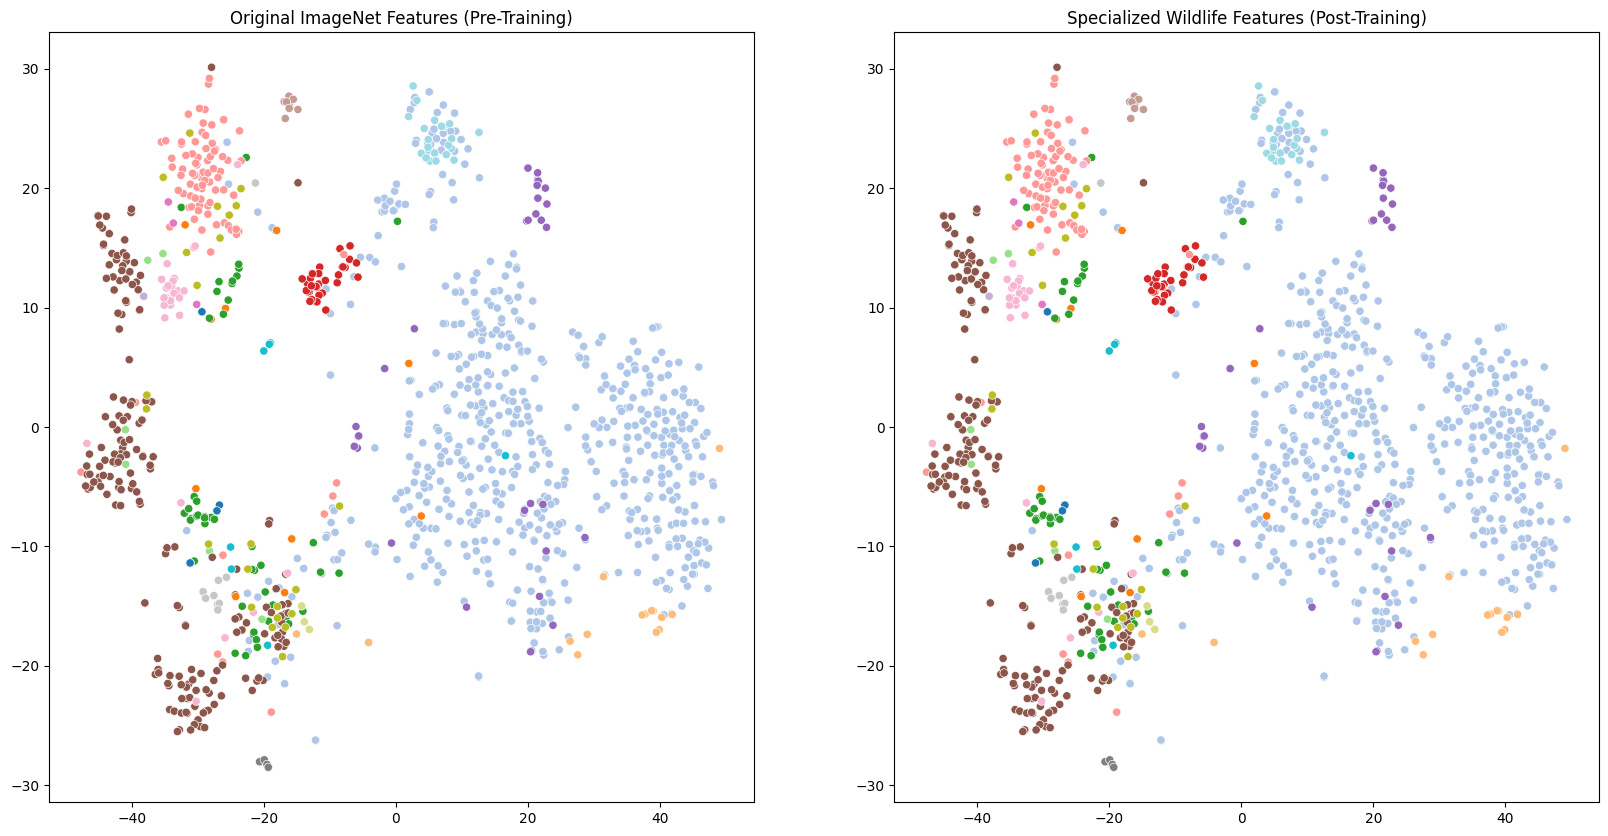

In [ ]:
def plot_tsne(data, labels, title):
    reduced = TSNE(n_components=2, random_state=42).fit_transform(data)
    sns.scatterplot(x=reduced[:,0], y=reduced[:,1], hue=labels, palette='tab20', legend=False)
    plt.title(title)

plt.figure(figsize=(20, 10))

# Left side: What the model saw BEFORE you trained it
plt.subplot(1, 2, 1)
plot_tsne(raw_embeddings, y_true_train, "Original ImageNet Features (Pre-Training)")

# Right side: What the model sees NOW
plt.subplot(1, 2, 2)
plot_tsne(custom_embeddings, y_true_train, "Specialized Wildlife Features (Post-Training)")

In [ ]:
# 1. Get a weight sample from your trained model
trained_weights = model.get_layer('efficientnetv2-b1').get_weights()[0]

# 2. Load a fresh, untouched base model
fresh_base = tf.keras.applications.EfficientNetV2B1(weights='imagenet', include_top=False)
fresh_weights = fresh_base.get_weights()[0]

# 3. Compare them
diff = np.sum(trained_weights - fresh_weights)

if diff == 0:
    print("CRITICAL: The weights are identical. Your training did not update the base model.")
else:
    print(f"Success: The weights have shifted by {diff:.4f}. The model HAS learned.")

print(trained_weights, fresh_weights)

CRITICAL: The weights are identical. Your training did not update the base model.


In [ ]:
# 1. Save the model in the modern .keras format
# This saves the architecture, weights, and the optimizer state
model.save("models/kalahari_species_model.keras")

# 2. Save your class names to a labels.txt file
# This is crucial for your function to translate numbers back to names
with open("models/labels.txt", "w") as f:
    for s in test_species_names:
        f.write(f"{s}\n")

print("✅ Model and Labels saved to the 'models' folder.")